# Publication-Quality Ordination Plots with ggplot2

## Overview

This notebook consolidates ordination visualization into a set of reusable, publication-ready plot templates. All plots use ggplot2 and are fully customizable. They build on the methods in `pca.ipynb`, `nmds.ipynb`, and `dbrda.ipynb`.

| Plot type | Method | Key elements |
|---|---|---|
| Ordination scatter | Any | Site scores, group ellipses, stress annotation |
| Biplot | PCA, dbRDA | Site scores + variable loading arrows + text labels |
| Triplot | dbRDA | Sites + species + environmental vectors |
| Ordination + envfit vectors | NMDS | Sites + significant environmental arrows |
| Dendrogram + ordination | Hierarchical clustering + NMDS | Clusters overlaid on ordination |

---

## Setup and Reference Data

In [1]:
library(tidyverse)
library(ggplot2)
library(vegan)
library(ggrepel)
library(patchwork)

set.seed(42)

# ── Simulate all reference data in one block ──────────────────────────────────
n_sites <- 45; n_sp <- 20
habitat <- rep(c("reference", "degraded", "restored"), each = 15)

ref_m  <- c(8,7,6,5,5,4,3,3,2,2,1,1,0,0,0,0,0,0,0,0)
deg_m  <- c(0,0,1,1,2,3,4,5,6,7,8,6,4,2,1,0,0,0,0,0)
rest_m <- c(4,4,4,3,3,3,3,2,2,2,2,2,1,1,1,0,0,0,0,0)

sim_c <- function(n, mu, sd=0.7)
  t(replicate(n, pmax(round(exp(rnorm(n_sp, log(mu+0.1), sd))), 0L)))

comm_mat <- rbind(sim_c(15,ref_m), sim_c(15,deg_m), sim_c(15,rest_m))
rownames(comm_mat) <- paste0("site",1:n_sites)
colnames(comm_mat) <- paste0("sp",1:n_sp)

env_df <- tibble(
  site    = paste0("site",1:n_sites),
  habitat = factor(habitat, levels=c("reference","degraded","restored")),
  pH      = c(rnorm(15,7.8,.3), rnorm(15,6.5,.6), rnorm(15,7.2,.4)),
  nitrate = c(rnorm(15,.5,.2),  rnorm(15,3.5,.9), rnorm(15,1.5,.4))
)

dist_bray <- vegan::vegdist(comm_mat, method="bray")
nmds      <- vegan::metaMDS(dist_bray, k=2, trymax=100, trace=0)

# ── Define shared color palette ───────────────────────────────────────────────
hab_pal <- c(reference="#4a8fff", degraded="#ff6b6b", restored="#4fffb0")

cat("Data and NMDS ready.\n")

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'vegan' was built under R version 4.4.3"
Loading required package: permute

Warning message:
"package 'patc

Data and NMDS ready.


---

## Template 1: Clean Ordination Scatter (NMDS or PCoA)

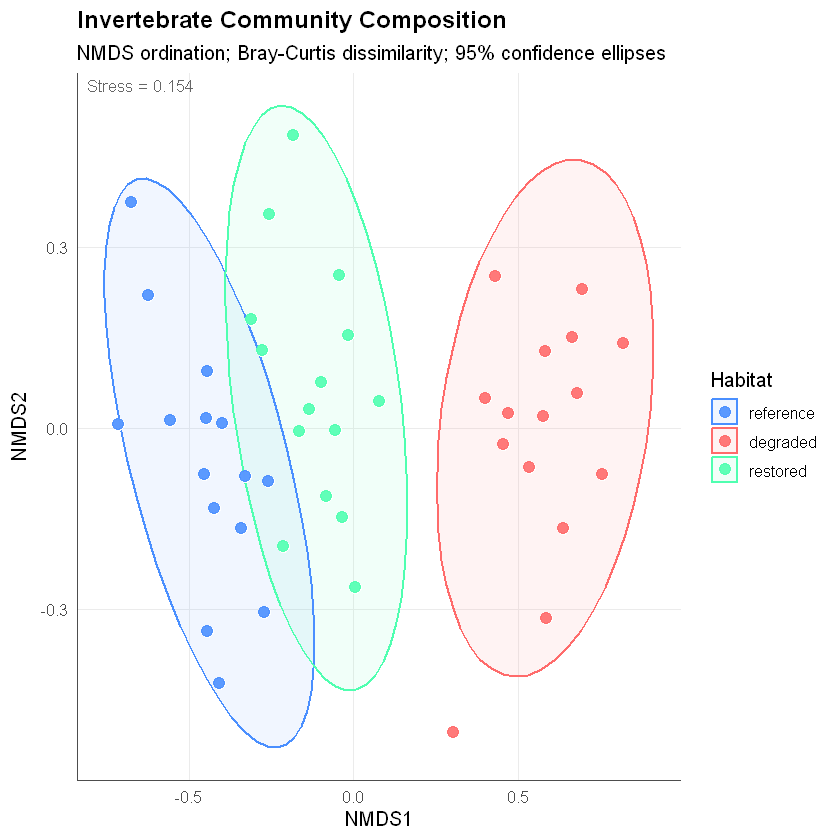

In [2]:
# ── Extract scores and join metadata ─────────────────────────────────────────
site_scores <- vegan::scores(nmds, display="sites") %>%
  as.data.frame() %>%
  rownames_to_column("site") %>%
  left_join(env_df, by="site")

# ── Build plot ────────────────────────────────────────────────────────────────
p_scatter <- ggplot(site_scores, aes(x=NMDS1, y=NMDS2,
                                      color=habitat, fill=habitat)) +
  stat_ellipse(geom="polygon", alpha=0.08, level=0.95, linewidth=0.8) +
  stat_ellipse(level=0.95, linewidth=0.8, show.legend=FALSE) +
  geom_point(size=3.5, alpha=0.9, stroke=0.4, color="white",
             show.legend=FALSE) +
  geom_point(size=3, alpha=0.9) +
  annotate("text", x=-Inf, y=Inf,
           label=sprintf("Stress = %.3f", nmds$stress),
           hjust=-0.1, vjust=1.4, size=3.5, color="gray40") +
  scale_color_manual(values=hab_pal, name="Habitat") +
  scale_fill_manual(values=hab_pal, name="Habitat") +
  labs(
    title    = "Invertebrate Community Composition",
    subtitle = "NMDS ordination; Bray-Curtis dissimilarity; 95% confidence ellipses",
    x = "NMDS1", y = "NMDS2"
  ) +
  theme_minimal(base_size=12) +
  theme(
    panel.grid.minor  = element_blank(),
    legend.position   = "right",
    plot.title        = element_text(face="bold"),
    axis.line         = element_line(color="gray30")
  )

print(p_scatter)

---

## Template 2: NMDS + envfit Vectors

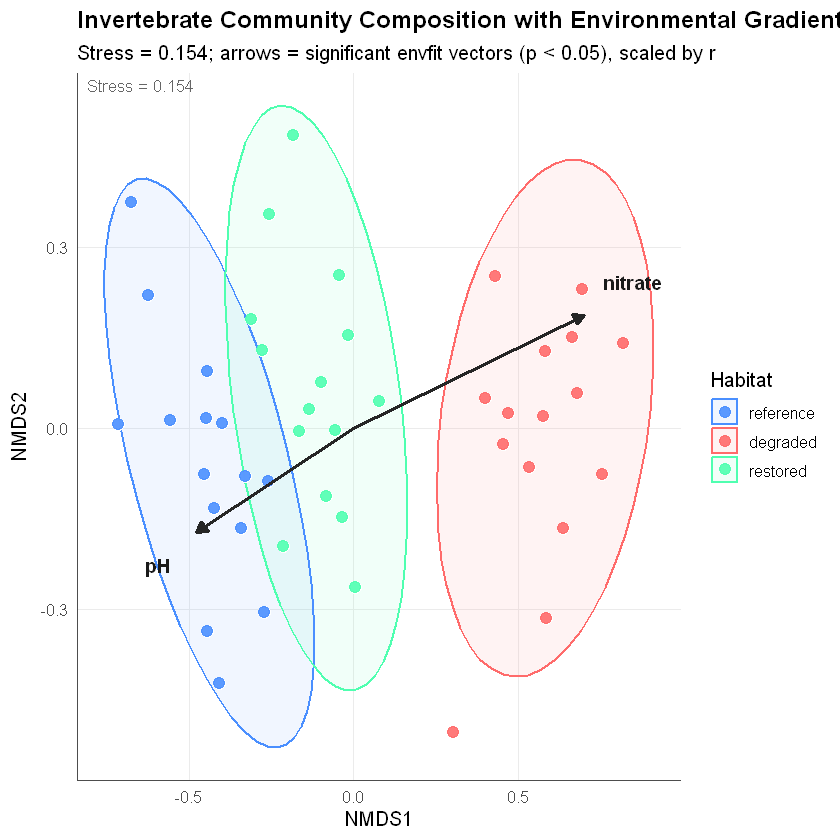

In [3]:
# ── Fit and extract significant env vectors ───────────────────────────────────
env_mat <- env_df %>% select(pH, nitrate) %>% as.matrix()
rownames(env_mat) <- env_df$site
ef <- vegan::envfit(nmds, env_mat, permutations=999)

env_vec <- vegan::scores(ef, display="vectors") %>%
  as.data.frame() %>%
  rownames_to_column("variable") %>%
  mutate(
    r2 = ef$vectors$r,
    p  = ef$vectors$pvals
  ) %>%
  filter(p < 0.05) %>%
  mutate(NMDS1 = NMDS1 * sqrt(r2),   # scale by r for display
         NMDS2 = NMDS2 * sqrt(r2))

# ── Build plot ────────────────────────────────────────────────────────────────
p_envfit <- p_scatter +
  geom_segment(
    data = env_vec,
    aes(x=0, y=0, xend=NMDS1, yend=NMDS2),
    inherit.aes = FALSE,
    arrow = arrow(length=unit(0.25,"cm"), type="closed"),
    color = "gray15", linewidth = 1.0
  ) +
  ggrepel::geom_text_repel(
    data = env_vec,
    aes(x=NMDS1*1.15, y=NMDS2*1.15, label=variable),
    inherit.aes = FALSE,
    size=4, fontface="bold", color="gray10",
    box.padding=0.3
  ) +
  labs(
    title    = "Invertebrate Community Composition with Environmental Gradients",
    subtitle = sprintf("Stress = %.3f; arrows = significant envfit vectors (p < 0.05), scaled by r",
                       nmds$stress)
  )

print(p_envfit)

---

## Template 3: PCA Biplot

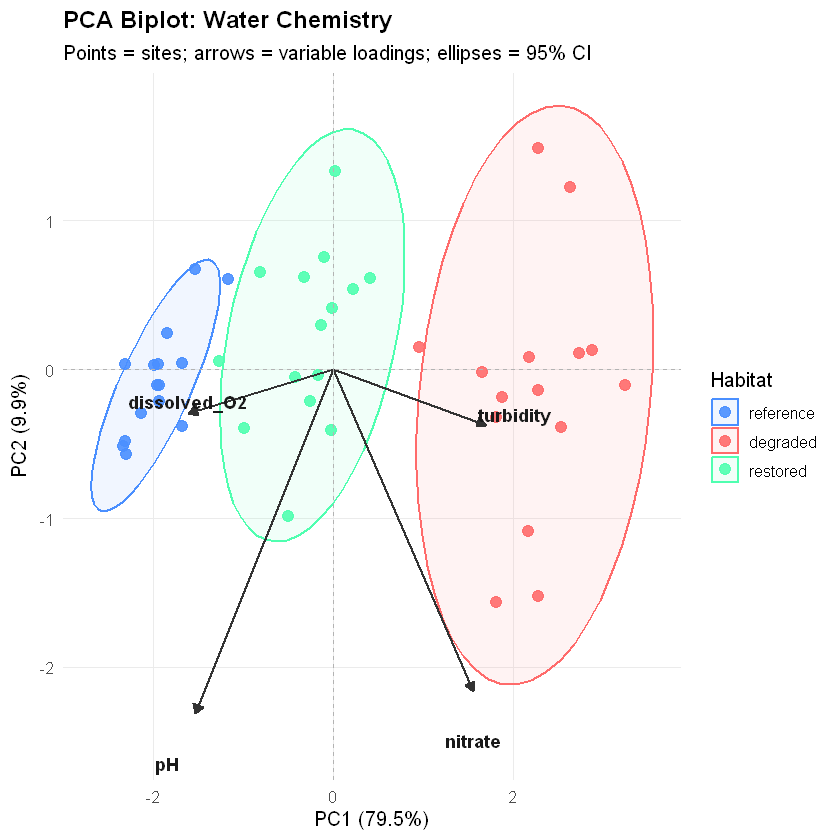

In [4]:
# ── PCA on environmental variables ────────────────────────────────────────────
env_vars <- env_df %>%
  mutate(turbidity  = c(rnorm(15,3,1), rnorm(15,12,2.5), rnorm(15,6,1.5)),
         dissolved_O2 = c(rnorm(15,9.5,.8), rnorm(15,6,1.5), rnorm(15,8,1))) %>%
  select(pH, nitrate, turbidity, dissolved_O2)

pca <- prcomp(env_vars, scale.=TRUE)
pct <- round(pca$sdev^2 / sum(pca$sdev^2) * 100, 1)

scores_df <- as.data.frame(pca$x[,1:2]) %>%
  mutate(habitat = env_df$habitat)

scale_f   <- 3.2
load_df   <- as.data.frame(pca$rotation[,1:2]) %>%
  rownames_to_column("variable") %>%
  mutate(PC1e = PC1*scale_f, PC2e = PC2*scale_f)

# ── Build biplot ──────────────────────────────────────────────────────────────
p_biplot <- ggplot() +
  # Site scores
  stat_ellipse(data=scores_df,
               aes(x=PC1, y=PC2, color=habitat, fill=habitat),
               geom="polygon", alpha=0.08, level=0.95, linewidth=0.7) +
  stat_ellipse(data=scores_df,
               aes(x=PC1, y=PC2, color=habitat),
               level=0.95, linewidth=0.7, show.legend=FALSE) +
  geom_point(data=scores_df, aes(x=PC1, y=PC2, color=habitat),
             size=3, alpha=0.9) +
  # Loading arrows
  geom_segment(data=load_df,
               aes(x=0, y=0, xend=PC1e, yend=PC2e),
               arrow=arrow(length=unit(0.22,"cm"), type="closed"),
               color="gray20", linewidth=0.8) +
  ggrepel::geom_text_repel(data=load_df,
                            aes(x=PC1e*1.1, y=PC2e*1.1, label=variable),
                            size=3.8, fontface="bold", color="gray10",
                            box.padding=0.3) +
  geom_hline(yintercept=0, linetype="dashed", color="gray70", linewidth=0.4) +
  geom_vline(xintercept=0, linetype="dashed", color="gray70", linewidth=0.4) +
  scale_color_manual(values=hab_pal, name="Habitat") +
  scale_fill_manual(values=hab_pal, name="Habitat") +
  labs(
    title    = "PCA Biplot: Water Chemistry",
    subtitle = "Points = sites; arrows = variable loadings; ellipses = 95% CI",
    x = sprintf("PC1 (%.1f%%)", pct[1]),
    y = sprintf("PC2 (%.1f%%)", pct[2])
  ) +
  theme_minimal(base_size=12) +
  theme(panel.grid.minor=element_blank(), plot.title=element_text(face="bold"))

print(p_biplot)

---

## Template 4: Multi-Panel Figure

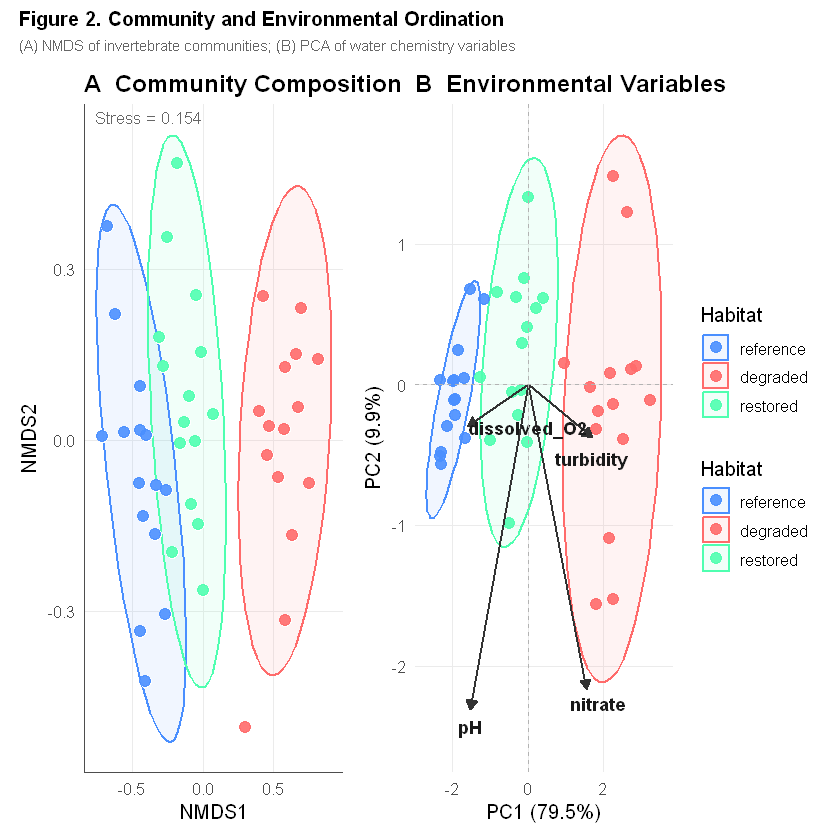

In [5]:
# ── Combine into a two-panel publication figure ───────────────────────────────
(p_scatter + labs(title="A  Community Composition", subtitle=NULL)) +
(p_biplot  + labs(title="B  Environmental Variables", subtitle=NULL)) +
patchwork::plot_layout(guides="collect") +
patchwork::plot_annotation(
  title    = "Figure 2. Community and Environmental Ordination",
  subtitle = "(A) NMDS of invertebrate communities; (B) PCA of water chemistry variables",
  theme    = theme(plot.title    = element_text(face="bold", size=12),
                   plot.subtitle = element_text(size=9, color="gray40"))
)

---

## Exporting Publication-Quality Figures

In [6]:
# ── Save as high-resolution TIFF or PDF ───────────────────────────────────────

# TIFF (most journals accept)
ggsave("nmds_plot.tiff",
       plot   = p_envfit,
       width  = 16, height = 12, units = "cm",
       dpi    = 300, compression = "lzw")

# PDF (vector — scales to any size without pixelation)
ggsave("nmds_plot.pdf",
       plot  = p_envfit,
       width = 16, height = 12, units = "cm")

# PNG (presentations and web)
ggsave("nmds_plot.png",
       plot  = p_envfit,
       width = 16, height = 12, units = "cm",
       dpi   = 300)

# ── Common journal size requirements ──────────────────────────────────────────
# Single column: ~8 cm wide
# Double column: ~16 cm wide
# Full page:     ~16 × 20 cm
# Font sizes on figures should be 7-9pt in the final printed size

# ── Check: if text appears too small/large in the saved file ─────────────────
# Adjust base_size in theme_minimal(base_size = X) — start at 8-10 for
# single-column figures, 10-12 for double-column
cat("Figures saved.\n")

Figures saved.


---

## Common Pitfalls

**1. Not displaying the stress value on NMDS plots**  
Any NMDS ordination without a stress annotation is uninterpretable. Always add stress as a text annotation — reviewers will ask for it.

**2. Using the default `plot.cca()` or `ordiplot()` for publications**  
Base R ordination plots are fine for exploration but difficult to customize and do not produce print-quality output. Rebuild in ggplot2 using extracted scores for publication figures.

**3. Scaling loading arrows inconsistently**  
Arrow length in biplots should be scaled consistently across all variables, not stretched to fill the plot. Scaling by r² (for envfit) or by a single fixed factor (for PCA loadings) keeps relative lengths meaningful.

**4. Overlapping labels**  
Species and variable labels in biplots almost always overlap. Use `ggrepel::geom_text_repel()` — never place labels manually.

**5. Saving at insufficient resolution**  
Raster formats (PNG, TIFF) must be saved at ≥ 300 DPI for print. For fully scalable output, save as PDF or SVG — these are vector formats that look sharp at any size.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*